## Load functions

In [1]:
from getpass import getuser # Libaray to copy things
from pathlib import Path # Object oriented libary to deal with paths
import os
from tempfile import NamedTemporaryFile, TemporaryDirectory # Creating temporary Files/Dirs
from subprocess import run, PIPE
import sys
 
import dask # Distributed data libary
from dask_jobqueue import SLURMCluster # Setting up distributed memories via slurm
from distributed import Client, progress, wait # Libaray to orchestrate distributed resources
import xarray as xr # Libary to work with labeled n-dimensional data and dask

In [2]:
# Set some user specific variables
scratch_dir = Path('/scratch') / getuser()[0] / getuser() # Define the users scratch dir
# Create a temp directory where the output of distributed cluster will be written to, after this notebook
# is closed the temp directory will be closed
dask_tmp_dir = TemporaryDirectory(dir=scratch_dir, prefix='PostProc')
cluster = SLURMCluster(memory='400GiB',
                       cores=72,
                       project='mh0731',
                       walltime='1:00:00',
                       queue='compute',
                       name='PostProc',
                   #    scheduler_options={'dashboard_address': ':12435'},
                       local_directory=dask_tmp_dir.name,
                       job_extra=[f'-J PostProc', 
                                  f'-D {dask_tmp_dir.name}',
                                  f'--begin=now',
                                  f'--output={dask_tmp_dir.name}/LOG_cluster.%j.o',
                                  f'--output={dask_tmp_dir.name}/LOG_cluster.%j.o'
                                 ],
                       interface='ib0')
cluster.scale(jobs=1)
dask_client = Client(cluster)

/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/dask_jobqueue/slurm.py:55: FutureWarning: project has been renamed to account as this kwarg was used wit -A option. You are still using it (please also check config files). If you did not set account yet, project will be respected for now, but it will be removed in a future release. If you already set account, project is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/

In [3]:
from getpass import getuser # Libaray to copy things
from tempfile import NamedTemporaryFile, TemporaryDirectory 

# scipy
from scipy import stats
from scipy.ndimage import measurements
from scipy import ndimage
from scipy.optimize import curve_fit

# for plot
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# basic
from pathlib import Path # Object oriented libary to deal with paths
import netCDF4 as nc
import numpy as np # Pythons standard array library
import xarray as xr # Libary to work with labeled n-dimensional data
import glob
import os

import easygems.healpix as egh
import healpy as hp

In [4]:
def contourf(data, latmin, latmax, lonmin, lonmax, vmin, vmax, cmap, extend, title):
    fig = plt.figure(figsize=[8,10],facecolor='w')
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

    ax.set_extent([lonmin,lonmax,latmin,latmax])
    ax.coastlines('50m',linewidth=0.8)
    gl = ax.gridlines(draw_labels=True, linewidth=1.5, color='gray',
                    xlocs=range(-180,180,20), ylocs=range(-90,90,10), crs=ccrs.PlateCarree())
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style, gl.ylabel_style = {'fontsize': 25}, {'fontsize': 25}
    # manipulate `gridliner` object
    gl.xlabels_top = False
    gl.ylabels_left = False
    gl.xlines = False
    gl.ylines = False

    # define lat and lon
    lats = data.lat
    lons = data.lon

    # Apply the same threshold to both datasets (pr_ctl_mm_hour_mask_q99_counts)
    #m = data.sum('hour').plot(levels=np.linspace(0, 20, 10), extend='max', cmap='YlGnBu', transform=ccrs.PlateCarree())
    #m = ax.pcolormesh(lons,lats,data.sum('hour'),cmap=cmap,vmin=vmin,vmax=vmax,transform=ccrs.PlateCarree())
    m = ax.pcolormesh(lons,lats,data,cmap=cmap,vmin=vmin,vmax=vmax,transform=ccrs.PlateCarree())

    #ax.clabel(a, inline=True, fontsize=20)
    #ax.clabel(b, inline=True, fontsize=20)

    kw = {'levels':[-1], 'colors':['grey'], 'linestyles':['solid']}
    plot_bd = AMZ_BD.plot.contour( 
                    ax=ax,
                    transform=ccrs.PlateCarree(),
                    **kw
                    )
    bounds = np.linspace(vmin, vmax, 11)
    cb = plt.colorbar(m, orientation="horizontal", fraction=0.05, pad=0.10, extend=extend,ticks=bounds, boundaries=bounds)
    cb.ax.tick_params(labelsize=25)
    cb.ax.set_xticklabels(bounds,rotation=270)
    plt.title(title, fontsize='20')
    plt.show()

In [5]:
def get_amazon_index(nside=12**2, nest=True):
    amazon = xr.open_dataset(
        "/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc"
    ).stack(cell=("latitude", "longitude"))
    
    is_amazon = amazon.where(amazon.AMAZON_BIOMES == 0, drop=True)
    
    return np.unique(hp.ang2pix(nside, is_amazon.longitude.values, is_amazon.latitude.values, nest=nest, lonlat=True)).astype(int)


## Load datasets - sm

### ICON (AMIP) - Cathy's run

In [6]:
sm1_ctl = xr.open_mfdataset('/scratch/m/m300948/AMIP_cathy/sm/amip_sm_lv1.nc',parallel=True, chunks={'time': 1, 'soil_depth_water':-1, 'lat': -1, 'lon': -1})['hydro_wtr_soil_sl_box']

In [7]:
sm2_ctl = xr.open_mfdataset('/scratch/m/m300948/AMIP_cathy/sm/amip_sm_lv2.nc',parallel=True, chunks={'time': 1, 'soil_depth_water':-1, 'lat': -1, 'lon': -1})['hydro_wtr_soil_sl_box']

In [8]:
sm3_ctl = xr.open_mfdataset('/scratch/m/m300948/AMIP_cathy/sm/amip_sm_lv3.nc',parallel=True, chunks={'time': 1, 'soil_depth_water':-1, 'lat': -1, 'lon': -1})['hydro_wtr_soil_sl_box']

### ICON Coupled

In [9]:
# ICON CTL (5km)
import intake
cat = intake.open_catalog("https://data.nextgems-h2020.eu/catalog.yaml")
data_ctl  = cat['ICON.C5.AMIP_CNTL'](time="P1D",zoom=8, grid=f"R02B08", chunks="auto").to_dask().pipe(egh.attach_coords) # 1979-1997 (19 years) original: zoom8

/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [10]:
dx_ngc = cat.ICON.ngc4008(zoom=8).to_dask().pipe(egh.attach_coords)
dx_ngc_start = dx_ngc.sel(time=slice('2024-01-01', '2028-12-31')) # 5 years
dx_ngc_end = dx_ngc.sel(time=slice('2045-01-01', '2049-12-31')) # 5years

/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


## Mask the Amazon basin

#### AMIP

In [11]:
dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
AMZ_BD = dset_bd.AMAZON_BIOMES

In [12]:
ABinterp_biome = AMZ_BD.interp(latitude=sm1_ctl.lat, longitude=sm1_ctl.lon)

In [13]:
sm1_ctl_mask = sm1_ctl.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
sm2_ctl_mask = sm2_ctl.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
sm3_ctl_mask = sm3_ctl.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

#### NGC4

In [14]:
# NGC4
is_amazon_ngc = get_amazon_index(nside=egh.get_nside(dx_ngc))
dx_ngc_start_amz = dx_ngc_start.isel(cell=is_amazon_ngc)
dx_ngc_end_amz = dx_ngc_end.isel(cell=is_amazon_ngc)

In [15]:
sm1_ngcs_mask = dx_ngc_start_amz.hydro_wtr_soil_sl_box.isel(soil_depth_water_level=0)
sm2_ngcs_mask = dx_ngc_start_amz.hydro_wtr_soil_sl_box.isel(soil_depth_water_level=1)
sm3_ngcs_mask = dx_ngc_start_amz.hydro_wtr_soil_sl_box.isel(soil_depth_water_level=2)

In [16]:
sm1_ngce_mask = dx_ngc_end_amz.hydro_wtr_soil_sl_box.isel(soil_depth_water_level=0)
sm2_ngce_mask = dx_ngc_end_amz.hydro_wtr_soil_sl_box.isel(soil_depth_water_level=1)
sm3_ngce_mask = dx_ngc_end_amz.hydro_wtr_soil_sl_box.isel(soil_depth_water_level=2)

## Monthly mean

#### amip

In [17]:
sm1_ctl_mask_mon = sm1_ctl_mask.isel(soil_depth_water=0).mean(('lat','lon')).resample(time="1M").mean().groupby("time.month").mean("time").load()
sm2_ctl_mask_mon = sm2_ctl_mask.isel(soil_depth_water=0).mean(('lat','lon')).resample(time="1M").mean().groupby("time.month").mean("time").load()
sm3_ctl_mask_mon = sm3_ctl_mask.isel(soil_depth_water=0).mean(('lat','lon')).resample(time="1M").mean().groupby("time.month").mean("time").load()

/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/xarray/groupers.py:543: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/xarray/groupers.py:543: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/xarray/groupers.py:543: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


#### icon_c

In [18]:
sm1_ngc_mask_mon = sm1_ngcs_mask.mean(('cell')).resample(time="1M").mean().groupby("time.month").mean("time").load()
sm2_ngc_mask_mon = sm2_ngcs_mask.mean(('cell')).resample(time="1M").mean().groupby("time.month").mean("time").load()
sm3_ngc_mask_mon = sm3_ngcs_mask.mean(('cell')).resample(time="1M").mean().groupby("time.month").mean("time").load()

/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/xarray/groupers.py:543: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/xarray/groupers.py:543: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/xarray/groupers.py:543: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


In [19]:
sm1_ngce_mask_mon = sm1_ngce_mask.mean(('cell')).resample(time="1M").mean().groupby("time.month").mean("time").load()
sm2_ngce_mask_mon = sm2_ngce_mask.mean(('cell')).resample(time="1M").mean().groupby("time.month").mean("time").load()
sm3_ngce_mask_mon = sm3_ngce_mask.mean(('cell')).resample(time="1M").mean().groupby("time.month").mean("time").load()

/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/xarray/groupers.py:543: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/xarray/groupers.py:543: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/xarray/groupers.py:543: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


_Total soil moisture_

In [20]:
levels = [0.0325, 0.192, 0.7755]

In [21]:
var = 'sm'
var_icon = 'hydro_wtr_soil_sl_box' 
results = {}

In [22]:
# level1 0.0325
sm_lv1_ngc_start_amz = sm1_ngcs_mask
sm_lv1_ngc_end_amz = sm1_ngce_mask

In [23]:
sm_lv2_ngc_start_amz = sm2_ngcs_mask
sm_lv2_ngc_end_amz = sm2_ngce_mask

In [24]:
sm_lv3_ngc_start_amz = sm3_ngcs_mask
sm_lv3_ngc_end_amz = sm3_ngce_mask

In [25]:
sm_ngc_start_amz = sm_lv1_ngc_start_amz + sm_lv2_ngc_start_amz + sm_lv3_ngc_start_amz
sm_ngc_end_amz = sm_lv1_ngc_end_amz + sm_lv2_ngc_end_amz + sm_lv3_ngc_end_amz

## Plotting

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

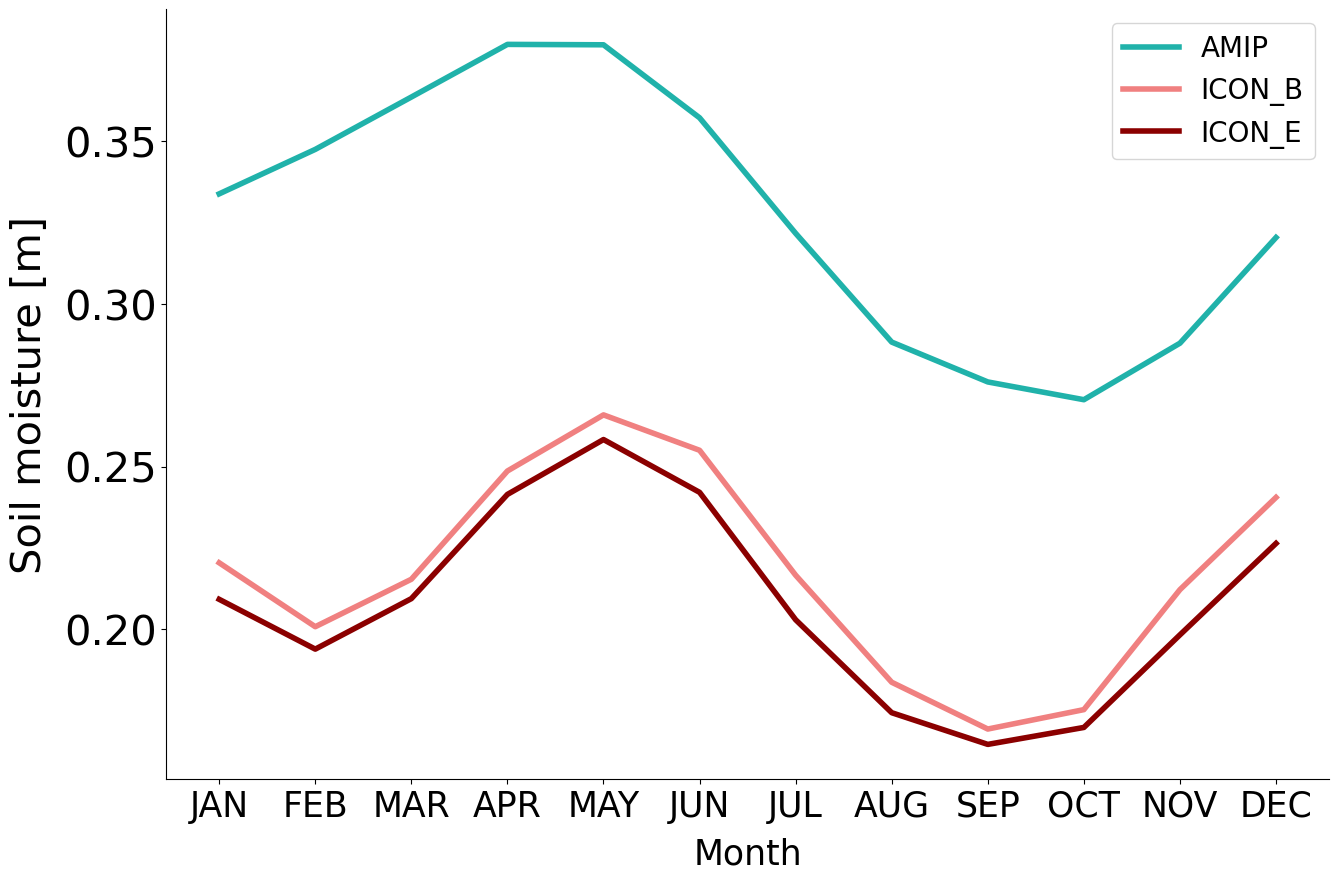

In [44]:
fig, ax = plt.subplots(figsize=(15,10))
plt.plot(sm1_ctl_mask_mon + sm2_ctl_mask_mon + sm3_ctl_mask_mon, label='AMIP',c='lightseagreen',linewidth=4)
plt.plot(sm1_ngc_mask_mon + sm2_ngc_mask_mon + sm3_ngc_mask_mon, label='ICON_B',c='lightcoral',linewidth=4)
plt.plot(sm1_ngce_mask_mon + sm2_ngce_mask_mon + sm3_ngce_mask_mon, label='ICON_E',c='darkred',linewidth=4)
plt.yticks(fontsize=30,family='Arial')
ax.set_ylabel('Soil moisture [m]',fontsize=30, labelpad = 10,family='Arial')
ax.set_xlabel('Month',fontsize=25, labelpad = 10)
#plt.xlabel('Difference tas [mm/day]',fontsize=25, labelpad = 20)
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11],['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC'],fontsize=25,family='Arial')
#plt.ylim(290,310)
ax.spines[['right', 'top']].set_visible(False)
plt.legend(fontsize=20)

In [46]:
a = sm1_ctl_mask_mon + sm2_ctl_mask_mon + sm3_ctl_mask_mon
print(a.mean(dim='month').values)

0.3272498


In [47]:
b = sm1_ngc_mask_mon + sm2_ngc_mask_mon + sm3_ngc_mask_mon
print(b.mean(dim='month').values)

0.21699603


## Load datasets - EF

#### AMIP - Cathy's run

In [26]:
lh_amip = xr.open_mfdataset('/scratch/m/m300948/AMIP_cathy/lh/amip_lh.nc',parallel=True, chunks={'time': 1, 'lat': -1, 'lon': -1})['hfls']
sh_amip = xr.open_mfdataset('/scratch/m/m300948/AMIP_cathy/sh/amip_sh.nc',parallel=True, chunks={'time': 1, 'lat': -1, 'lon': -1})['hfss']

In [27]:
ABinterp_biome_ef = AMZ_BD.interp(latitude=lh_amip.lat, longitude=lh_amip.lon)

In [28]:
lh_amip_amz = lh_amip.where(ABinterp_biome_ef == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
sh_amip_amz = sh_amip.where(ABinterp_biome_ef == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [65]:
# LH remove the time when values above 0
ds = lh_amip_amz.compute()
mask_above_0 = ds > 0 
lh_amip_amz_mask = ds.where(~mask_above_0.any(dim=['lat','lon']), drop=True) 

In [69]:
common_times = np.intersect1d(lh_amip_amz_mask['time'], sh_amip_amz['time'])

# Step 2: Select common days from each dataset
lh_amip_common = lh_amip_amz_mask.sel(time=common_times)
sh_amip_common = sh_amip_amz.sel(time=common_times)
#lh_amip_common = lh_amip_amz.sel(time=common_times)

In [70]:
EF_amip_amz = lh_amip_common / (lh_amip_common + sh_amip_common)

In [108]:
ds = EF_amip_amz.compute()
min_val = ds.min()
mask = ds == min_val

time_of_min = ds['time'].where(mask.any(dim=['lat','lon']), drop=True)

/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 720.75 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [109]:
time_of_min

<xarray.DataArray 'time' (time: 1)> Size: 8B
array(['1996-10-02T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 8B 1996-10-02
Attributes:
    standard_name:  time
    axis:           T

In [ ]:
ds = EF_amip_amz.compute()
max_val = ds.max()
mask = ds == max_val

time_of_max = ds['time'].where(mask.any(dim=['lat','lon']), drop=True)

/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 720.75 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [72]:
time_of_max

<xarray.DataArray 'time' (time: 1)> Size: 8B
array(['2000-10-20T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 8B 2000-10-20
Attributes:
    standard_name:  time
    axis:           T

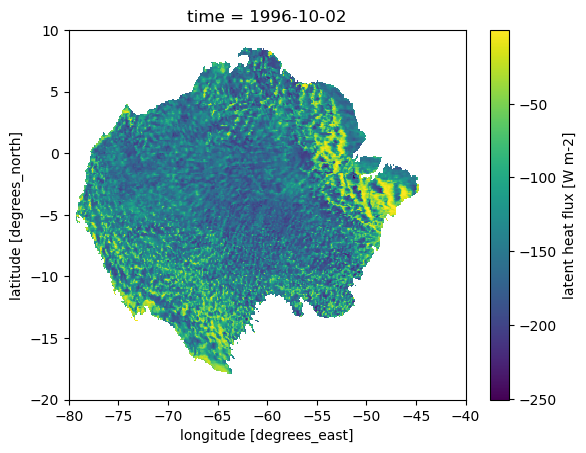

In [112]:
lh_amip_amz.sel(time='1996-10-02').plot()

In [74]:
EF_amip_amz_mon = EF_amip_amz.mean(('lat','lon')).resample(time="1M").mean().groupby("time.month").mean("time").load()

/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/xarray/groupers.py:543: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 720.94 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


#### AMIP

In [75]:
data_ctl  = cat['ICON.C5.AMIP_CNTL'](time="P1D",zoom=8, grid=f"R02B08", chunks="auto").to_dask().pipe(egh.attach_coords) # 1979-1997 (19 years) original: zoom8
dx_p4k  = cat['ICON.C5.AMIP_P4K'](time="P1D", zoom=8, grid=f"R02B08", chunks="auto").to_dask().pipe(egh.attach_coords) # 1979-1993 (15 years)
dx_4co2 = cat['ICON.C5.AMIP_4CO2'](time="P1D",zoom=8, grid=f"R02B08", chunks="auto").to_dask().pipe(egh.attach_coords) # 1980-1994 (15 years)

/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),
/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),
/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mappi

In [76]:
is_amazon = get_amazon_index(nside=egh.get_nside(data_ctl))
dx_ctl_amz = data_ctl.isel(cell=is_amazon).sel(time=slice("1980", "1994")) 
dx_p4k_amz = dx_p4k.isel(cell=is_amazon).sel(time=slice("1979", "1993"))
dx_4co2_amz = dx_4co2.isel(cell=is_amazon).sel(time=slice("1980", "1994"))

In [77]:
lh_ctl_amz = dx_ctl_amz.hfls
lh_p4k_amz = dx_p4k_amz.hfls
lh_4co2_amz = dx_4co2_amz.hfls

In [78]:
sh_ctl_amz = dx_ctl_amz.hfss
sh_p4k_amz = dx_p4k_amz.hfss
sh_4co2_amz = dx_4co2_amz.hfss

In [79]:
ef_ctl_amz = lh_ctl_amz / (lh_ctl_amz + sh_ctl_amz)
ef_p4k_amz = lh_p4k_amz / (lh_p4k_amz + sh_p4k_amz)
ef_4co2_amz = lh_4co2_amz / (lh_4co2_amz + sh_4co2_amz)

In [80]:
ef_ctl_amz_mon = ef_ctl_amz.mean(('cell')).resample(time="1M").mean().groupby("time.month").mean("time").load()
ef_p4k_amz_mon = ef_p4k_amz.mean(('cell')).resample(time="1M").mean().groupby("time.month").mean("time").load()
ef_4co2_amz_mon = ef_4co2_amz.mean(('cell')).resample(time="1M").mean().groupby("time.month").mean("time").load()

/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/xarray/groupers.py:543: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/xarray/groupers.py:543: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/xarray/groupers.py:543: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


In [31]:
# Comparison between Cathy's run and AMIP-CTL
print(lh_ctl_amz.mean(dim=('time','cell')).values)
print(sh_ctl_amz.mean(dim=('time','cell')).values)
print(EF_amip_amz_mon.mean(dim='month').values)

-125.832405
-30.24308
0.8296566


In [34]:
print(lh_amip_amz.mean(dim=('time','lat','lon')).values)
print(sh_amip_amz.mean(dim=('time','lat','lon')).values)
ef_ctl_amz_mon.mean(dim='month')

-125.80915
-26.408255


<xarray.DataArray ()> Size: 4B
array(0.80717707, dtype=float32)
Coordinates:
    healpix  int64 8B 0
Attributes:
    standard_name:  lhflx
    long_name:      latent heat flux
    units:          W m-2
    param:          10.0.0
    grid_mapping:   healpix

#### ngc4

_Heat fluxes_

In [81]:
hfls_ngc_mask = dx_ngc_start_amz.hfls #/28.94
hfss_ngc_mask = dx_ngc_start_amz.hfss #/28.94

In [82]:
ef_ngc_mask = hfls_ngc_mask / (hfls_ngc_mask + hfss_ngc_mask)
ef_ngc_mask_mon = ef_ngc_mask.mean(('cell')).resample(time="1M").mean().groupby("time.month").mean("time").load()

/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/xarray/groupers.py:543: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


In [ ]:
fig, ax = plt.subplots(figsize=(15,10))
plt.plot(EF_amip_amz_mon, label='AMIP EF',c='lightseagreen',linewidth=4)
plt.plot(ef_ngc_mask_mon, label='ICON_B',c='lightcoral',linewidth=4)

plt.plot(ef_ctl_amz_mon, label='CTL',c='black',linewidth=4)
plt.plot(ef_4co2_amz_mon, label='P4K',c='orange',linewidth=4)
plt.plot(ef_p4k_amz_mon, label='4CO2',c='red',linewidth=4)

plt.yticks(fontsize=30,family='Arial')
ax.set_ylabel('Evapotranspiration',fontsize=30, labelpad = 10,family='Arial')
ax.set_xlabel('Month',fontsize=25, labelpad = 10)
#plt.xlabel('Difference tas [mm/day]',fontsize=25, labelpad = 20)
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11],['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC'],fontsize=25,family='Arial')
#plt.ylim(290,310)
ax.spines[['right', 'top']].set_visible(False)
plt.legend(fontsize=20)

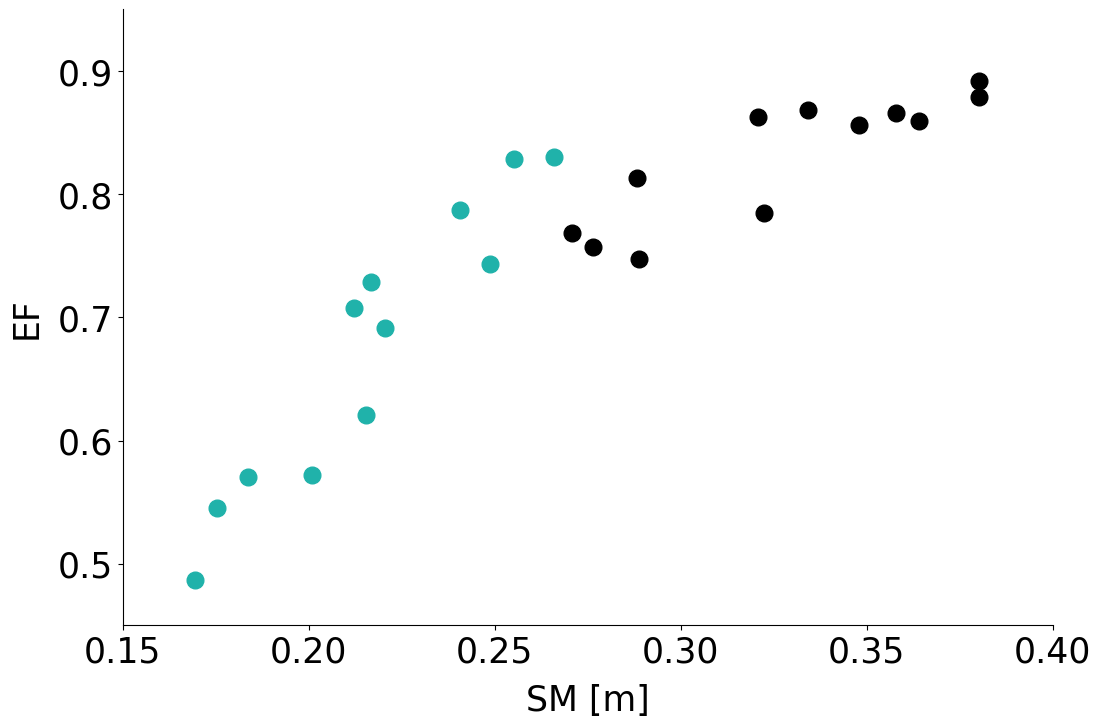

In [55]:
fig, ax = plt.subplots(figsize=(12,8))

y1 = ef_ngc_mask_mon.values
x1 = sm1_ngc_mask_mon.values + sm2_ngc_mask_mon.values + sm3_ngc_mask_mon.values
y3 = EF_amip_amz_mon.values # ef_ctl_amz_mon.values
x3 = sm1_ctl_mask_mon.values + sm2_ctl_mask_mon.values + sm3_ctl_mask_mon.values

plt.plot(x1, y1, 'o', color='lightseagreen', label='ICON_B',  markersize = 12)
plt.plot(x3, y3, 'o', label='CTL', c='black', markersize = 12)

plt.yticks(fontsize=25)
plt.xticks(fontsize=25)
ax.set_ylabel('EF',fontsize=25, labelpad = 10)
ax.set_xlabel('SM [m]',fontsize=25, labelpad = 10)
#plt.xlabel('Difference tas [mm/day]',fontsize=25, labelpad = 20)
plt.xlim(0.15,0.40)
plt.ylim(0.45, 0.95)
ax.spines[['right', 'top']].set_visible(False)
#plt.legend(fontsize=20)

## Budyko curve # 1

_AMIP-CTL (sub_CTLA)_

In [39]:
sm_ctl_mask = sm1_ctl_mask.isel(soil_depth_water=0)+sm2_ctl_mask.isel(soil_depth_water=0)+sm3_ctl_mask.isel(soil_depth_water=0)

In [40]:
common_times = np.intersect1d(sm_ctl_mask['time'], EF_amip_amz['time'])

# Step 2: Select common days from each dataset
sm_amip_common = sm_ctl_mask.sel(time=common_times)
EF_amip_common = EF_amip_amz.sel(time=common_times)
#lh_amip_common = lh_amip_amz.sel(time=common_times)

In [41]:
print(sm_amip_common.shape)
print(EF_amip_common.shape)

(1827, 300, 400)
(1827, 300, 400)


_ngc_

In [41]:
# NGC START
sm_ngc_start_amz = sm1_ngcs_mask + sm2_ngcs_mask + sm3_ngcs_mask

In [42]:
xarray_names = ['sm_amip_common','EF_amip_common'] #'lh_amip_common'
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [43]:
xarray_names = ['sm_ngc_start_amz','ef_ngc_mask'] # 'hfls_ngc_mask'
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

_Latent heat_

In [ ]:
xarray_names = ['sm_ngc_start_amz','ef_ngc_mask'] # 'hfls_ngc_mask'
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [37]:
print(np.shape(sm_amip_common_f), np.shape(EF_amip_common_f))

(97989318,) (97989318,)


In [38]:
print(np.shape(sm_ngc_start_amz_f), np.shape(ef_ngc_mask_f))

(19386297,) (19386297,)


In [ ]:
# NGC END
xarray_names = ['sm_ngc_end_amz','ef_ngce_amz']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

_Save the datasets_

In [40]:
print(np.mean(sm_amip_common_f), np.mean(EF_amip_common_f))
print(np.mean(sm_ngc_start_amz_f), np.mean(ef_ngc_mask_f))

0.32712308 0.82920057
0.21705319 0.6765121


_plotting_

In [46]:
import pandas as pd
# AMIP
df_1 = pd.DataFrame({'sm':EF_amip_common_f, 'lh': -lh_amip_common_f/28.94})  # Convert to mm/day
df_1 = df_1.dropna()
df_1 = df_1.sort_values('sm')
# NGC
df_2 = pd.DataFrame({'sm':ef_ngc_mask_f, 'lh': -hfls_ngc_mask_f})
df_2 = df_2.dropna()
df_2 = df_2.sort_values('sm')

# Bin the SM into intervals
df_1['sm_bin'] = pd.cut(df_1['sm'], bins=np.arange(0, 0.5, 0.05))
median_lh_1 = df_1.groupby('sm_bin')['lh'].median()
bin_centers_1 = [i.mid for i in median_lh_1.index]

df_2['sm_bin'] = pd.cut(df_2['sm'], bins=np.arange(0, 0.5, 0.05))
median_lh_2 = df_2.groupby('sm_bin')['lh'].median()
bin_centers_2 = [i.mid for i in median_lh_2.index]

fig, ax = plt.subplots(figsize=(7,5))
plt.plot(bin_centers_1, median_lh_1, color='black', label='Running Median',linewidth=2.5)
plt.plot(bin_centers_2, median_lh_2, color='blue', label='Running Median',linewidth=2.5)
plt.axvline(x=0.25, color='grey', linestyle='--', linewidth=2)
#plt.scatter(df_1['sm'], df_1['lh'], s=1, alpha=0.05, color='grey')
#plt.scatter(df_1['sm'], df_1['lh'], s=1, alpha=0.05, color='grey')
ax.set_ylabel('EVP [mm/day]',fontsize=15, labelpad = 10)
ax.set_xlabel('SM [m]',fontsize=15, labelpad = 10)
plt.yticks(fontsize=15)
plt.xticks(fontsize=15)
#plt.xlim(0.0, 0.5)
#plt.ylim(0,1)
ax.spines[['right', 'top']].set_visible(False)
#plt.legend()

NameError: name 'lh_amip_common_f' is not defined

_SM and HFLS Plotting_

In [45]:
print(np.mean(sm_amip_common_f)), 
print(np.mean(sm_ngc_start_amz_f)), 
print(np.mean(EF_amip_common_f)), 
print(np.mean(ef_ngc_mask_f))

0.32712308
0.21705319
0.82920057
0.6765121


_find the regime (AMIP)_

In [49]:
sm = np.array(bin_centers_amip)
ef = np.array(median_lh_amip)

In [50]:
from scipy.ndimage import gaussian_filter1d
ef_smooth = gaussian_filter1d(ef, sigma=1)  # tweak sigma if needed

In [51]:
import numpy as np

slope = np.gradient(ef_smooth, sm)
curvature = np.gradient(slope, sm)   # second derivative


In [52]:
from scipy.signal import find_peaks

# Peaks of |curvature|
peaks, _ = find_peaks(np.abs(curvature))

# Sort by magnitude and take the two largest
peak_order = np.argsort(np.abs(curvature[peaks]))[::-1]
main_peaks = peaks[peak_order[:2]]      # indices of two biggest regime changes
main_peaks.sort()

idx_dry_to_trans, idx_trans_to_wet = main_peaks
sm_dry_to_trans  = sm[idx_dry_to_trans]
sm_trans_to_wet  = sm[idx_trans_to_wet]

In [53]:
print(sm_dry_to_trans, sm_trans_to_wet) # AMIP 

0.125 0.275


_standard deviation_

In [54]:
# Standard deviation of EF in each SM bin (NGC)
std_lh_ngc = df_ngc.groupby('sm_bin')['ef'].std()
mean_ef_ngc = median_lh_ngc.values
std_ef_ngc  = std_lh_ngc.values
sm_bins_ngc = np.array(bin_centers_ngc)

# Upper and lower bounds
upper_ngc = mean_ef_ngc + std_ef_ngc
lower_ngc = mean_ef_ngc - std_ef_ngc

/tmp/ipykernel_899051/2747660706.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  std_lh_ngc = df_ngc.groupby('sm_bin')['ef'].std()


In [55]:
# Standard deviation of EF in each SM bin (AMIP)
std_lh_amip = df_amip.groupby('sm_bin')['ef'].std()
mean_ef_amip = median_lh_amip.values
std_ef_amip  = std_lh_amip.values
sm_bins_amip = np.array(bin_centers_amip)

# Upper and lower bounds
upper_amip = mean_ef_amip + std_ef_amip
lower_amip = mean_ef_amip - std_ef_amip

/tmp/ipykernel_899051/2214494631.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  std_lh_amip = df_amip.groupby('sm_bin')['ef'].std()


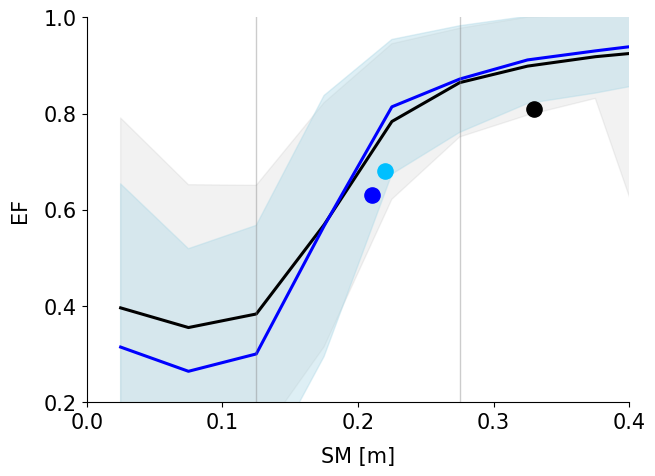

In [66]:
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(bin_centers_amip, median_lh_amip, color='black', label='CTL', linewidth=2.2) # AMIP = Black
ax.plot(bin_centers_ngc, median_lh_ngc, color='blue', label='NGCS', linewidth=2.2) # NGC = Blue
plt.fill_between(sm_bins_amip, lower_amip, upper_amip, alpha=0.1, color='grey') # blue
plt.fill_between(sm_bins_ngc, lower_ngc, upper_ngc, alpha=0.4, color='lightblue') # blue

# Error bar (std)
#plt.errorbar(sm_bins_amip, median_lh_amip, std_ef_amip, elinewidth=1, capsize=4, linewidth=0.2, c='black')
#plt.errorbar(sm_bins_ngc, median_lh_ngc, std_ef_ngc, elinewidth=1, capsize=4, linewidth=0.3, c='lightblue')


# your scatter points
ax.scatter(0.22, 0.68, color='deepskyblue', s=120, zorder=5) # NGCS
ax.scatter(0.21, 0.63, color='blue', s=120, zorder=5) # NGCE

ax.scatter(0.33, 0.81, color='black', s=120, zorder=5)
#ax.scatter(0.34, 0.82, color='orange', s=150, marker='*', alpha=0.5, zorder=5)
#ax.scatter(0.31, 0.79, color='red', s=150, marker='*', alpha=0.5, zorder=5)

# Shade regimes based on CTL
#ax.axvspan(0, sm_dry_to_trans, alpha=0.2, color='orange',   label='Dry')
#ax.axvspan(sm_dry_to_trans, sm_trans_to_wet, alpha=0.2, color='lightgreen', label='Transitional')
#ax.axvspan(sm_trans_to_wet, 0.5, alpha=0.2, color='lightblue', label='Wet')
ax.axvline(sm_dry_to_trans, color='grey', alpha=0.4, linewidth=1)
ax.axvline(sm_trans_to_wet, color='grey', alpha=0.4, linewidth=1)


ax.set_ylim(0.2, 1)
ax.set_xlim(0.0, 0.4)
ax.spines[['right', 'top']].set_visible(False)
ax.set_ylabel('EF', fontsize=15, labelpad=10)
ax.set_xlabel('SM [m]', fontsize=15, labelpad=10)
ax.set_yticks(np.arange(0.2, 1.01, 0.2))
ax.set_xticks(np.arange(0.0, 0.41, 0.1))
ax.tick_params(labelsize=15)
#ax.set_title("Median EF vs SM")
#ax.legend()


## Budyko curve # 2

_AMIP-CTL (sub_CTLA)_

In [83]:
sm_ctl_mask = sm1_ctl_mask.isel(soil_depth_water=0)+sm2_ctl_mask.isel(soil_depth_water=0)+sm3_ctl_mask.isel(soil_depth_water=0)

In [84]:
common_times = np.intersect1d(sm_ctl_mask['time'], EF_amip_amz['time'])

# Step 2: Select common days from each dataset
sm_amip_common = sm_ctl_mask.sel(time=common_times)
EF_amip_common = EF_amip_amz.sel(time=common_times)
#lh_amip_common = lh_amip_amz.sel(time=common_times)

In [85]:
print(sm_amip_common.shape)
print(EF_amip_common.shape)

(1572, 300, 400)
(1572, 300, 400)


In [86]:
xarray_names = ['sm_amip_common','EF_amip_common'] #'lh_amip_common'
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 720.81 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [87]:
print(np.size(sm_amip_common_f), np.size(EF_amip_common_f))

84312648 84312648


_ngc_

In [89]:
# NGC START
sm_ngc_start_amz = sm1_ngcs_mask + sm2_ngcs_mask + sm3_ngcs_mask

In [90]:
xarray_names = ['sm_ngc_start_amz','ef_ngc_mask'] # 'hfls_ngc_mask'
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [53]:
print(np.shape(sm_ngc_start_amz_f), np.shape(ef_ngc_mask_f))

(19386297,) (19386297,)


_Save the datasets_

In [60]:
print(np.mean(sm_amip_common_f), np.mean(EF_amip_common_f))
print(np.mean(sm_ngc_start_amz_f), np.mean(ef_ngc_mask_f))

0.016879857 0.8031618
0.21705319 0.6765121


_Check the values_

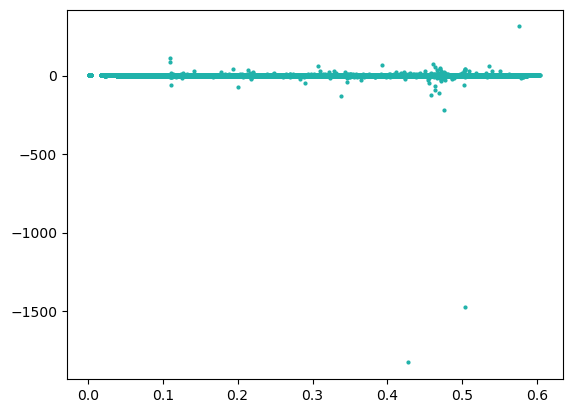

In [102]:
plt.plot(sm_amip_common_f, EF_amip_common_f, 'o', color='lightseagreen', label='ICON_B',  markersize = 2)

In [91]:
# remove values outside the non-realistic values
import pandas as pd
# AMIP
df_1 = pd.DataFrame({'sm':sm_amip_common_f, 'ef': EF_amip_common_f})  # Convert to mm/day
df_1 = df_1.dropna()
df_1 = df_1.sort_values('sm')

# Bin the SM into intervals
df_1['sm_bin'] = pd.cut(df_1['sm'], bins=np.arange(0, 0.55, 0.05))
mean_ef_1 = df_1.groupby('sm_bin')['ef'].mean()
bin_centers_1 = [i.mid for i in mean_ef_1.index]

/tmp/ipykernel_524315/120894794.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_ef_1 = df_1.groupby('sm_bin')['ef'].mean()


In [92]:
mean_ef_1

sm_bin
(0.0, 0.05]    0.392168
(0.05, 0.1]    0.350510
(0.1, 0.15]    0.380384
(0.15, 0.2]    0.567141
(0.2, 0.25]    0.783982
(0.25, 0.3]    0.864600
(0.3, 0.35]    0.898790
(0.35, 0.4]    0.918384
(0.4, 0.45]    0.931778
(0.45, 0.5]    0.943242
Name: ef, dtype: float32

_plotting (mean)_

/tmp/ipykernel_524315/1394362157.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_ef_1 = df_1.groupby('sm_bin')['ef'].mean()
/tmp/ipykernel_524315/1394362157.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_ef_2 = df_2.groupby('sm_bin')['ef'].mean()


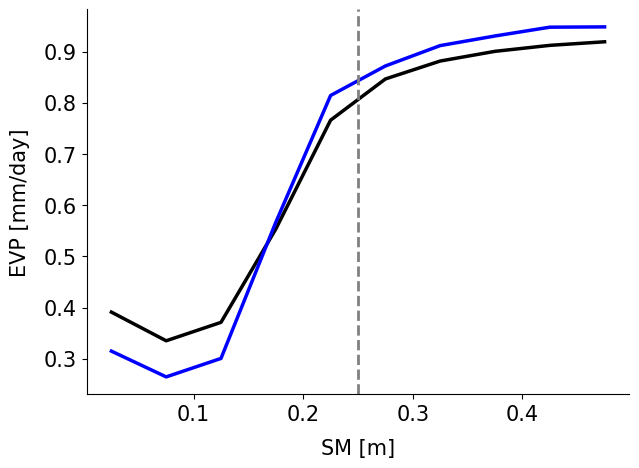

In [113]:
import pandas as pd
# AMIP
df_1 = pd.DataFrame({'sm':sm_amip_common_f, 'ef': EF_amip_common_f})  # Convert to mm/day
df_1 = df_1.dropna()
df_1 = df_1[(df_1['ef'] >= -500) & (df_1['ef'] <= 1)]
df_1 = df_1.sort_values('sm')
# NGC
df_2 = pd.DataFrame({'sm':sm_ngc_start_amz_f, 'ef': ef_ngc_mask_f})
df_2 = df_2.dropna()
df_2 = df_2.sort_values('sm')

# Bin the SM into intervals
df_1['sm_bin'] = pd.cut(df_1['sm'], bins=np.arange(0, 0.55, 0.05))
mean_ef_1 = df_1.groupby('sm_bin')['ef'].mean()
bin_centers_1 = [i.mid for i in mean_ef_1.index]

df_2['sm_bin'] = pd.cut(df_2['sm'], bins=np.arange(0, 0.55, 0.05))
mean_ef_2 = df_2.groupby('sm_bin')['ef'].mean()
bin_centers_2 = [i.mid for i in mean_ef_2.index]

fig, ax = plt.subplots(figsize=(7,5))
plt.plot(bin_centers_1, mean_ef_1, color='black', label='Running mean',linewidth=2.5)
plt.plot(bin_centers_2, mean_ef_2, color='blue', label='Running mean',linewidth=2.5)
plt.axvline(x=0.25, color='grey', linestyle='--', linewidth=2)
#plt.scatter(df_1['sm'], df_1['lh'], s=1, alpha=0.05, color='grey')
#plt.scatter(df_1['sm'], df_1['lh'], s=1, alpha=0.05, color='grey')
ax.set_ylabel('EVP [mm/day]',fontsize=15, labelpad = 10)
ax.set_xlabel('SM [m]',fontsize=15, labelpad = 10)
plt.yticks(fontsize=15)
plt.xticks(fontsize=15)
#plt.xlim(0.0, 0.5)
#plt.ylim(0,1)
ax.spines[['right', 'top']].set_visible(False)
#plt.legend()

In [108]:
print(sm_amip_common_f.max(), sm_ngc_start_amz_f.max())

0.60415196 0.51430213


In [109]:
bin_centers_1

[np.float64(0.025),
 np.float64(0.07500000000000001),
 np.float64(0.125),
 np.float64(0.175),
 np.float64(0.225),
 np.float64(0.275),
 np.float64(0.32499999999999996),
 np.float64(0.375),
 np.float64(0.42500000000000004),
 np.float64(0.475)]

In [110]:
counts = df_1.groupby('sm_bin')['ef'].count()
counts

/tmp/ipykernel_233964/636023584.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df_1.groupby('sm_bin')['ef'].count()


sm_bin
(0.0, 0.05]       45206
(0.05, 0.1]      628761
(0.1, 0.15]     5180852
(0.15, 0.2]    10910984
(0.2, 0.25]    11258753
(0.25, 0.3]    12318876
(0.3, 0.35]    13782502
(0.35, 0.4]    14214975
(0.4, 0.45]    13363576
(0.45, 0.5]    10659777
Name: ef, dtype: int64

In [111]:
counts = df_2.groupby('sm_bin')['ef'].count()
counts

/tmp/ipykernel_233964/1878464787.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df_2.groupby('sm_bin')['ef'].count()


sm_bin
(0.0, 0.05]      16373
(0.05, 0.1]     318391
(0.1, 0.15]    3240612
(0.15, 0.2]    5243939
(0.2, 0.25]    4436875
(0.25, 0.3]    3402822
(0.3, 0.35]    1993039
(0.35, 0.4]     646991
(0.4, 0.45]      80366
(0.45, 0.5]       6828
Name: ef, dtype: int64

_SM and HFLS Plotting_

In [91]:
print(np.mean(sm_amip_common_f)), 
print(np.mean(sm_ngc_start_amz_f)), 
print(np.mean(EF_amip_common_f)), 
print(np.mean(ef_ngc_mask_f))

0.32712308
0.21705319
0.82920057
0.6765121


_find the regime (AMIP)_

In [114]:
sm = np.array(bin_centers_1)
ef = np.array(mean_ef_1)

In [95]:
from scipy.ndimage import gaussian_filter1d
ef_smooth = gaussian_filter1d(ef, sigma=1)  # tweak sigma if needed

In [96]:
import numpy as np

slope = np.gradient(ef_smooth, sm)
curvature = np.gradient(slope, sm)   # second derivative


In [97]:
from scipy.signal import find_peaks

# Peaks of |curvature|
peaks, _ = find_peaks(np.abs(curvature))

# Sort by magnitude and take the two largest
peak_order = np.argsort(np.abs(curvature[peaks]))[::-1]
main_peaks = peaks[peak_order[:2]]      # indices of two biggest regime changes
main_peaks.sort()

idx_dry_to_trans, idx_trans_to_wet = main_peaks
sm_dry_to_trans  = sm[idx_dry_to_trans]
sm_trans_to_wet  = sm[idx_trans_to_wet]

In [98]:
print(sm_dry_to_trans, sm_trans_to_wet) # AMIP 

0.125 0.275


_standard deviation_

In [115]:
# Standard deviation of EF in each SM bin (NGC)
std_lh_ngc = df_2.groupby('sm_bin')['ef'].std()
mean_ef_ngc = mean_ef_2.values
std_ef_ngc  = std_lh_ngc.values
sm_bins_ngc = np.array(bin_centers_2)

# Upper and lower bounds
upper_ngc = mean_ef_ngc + std_ef_ngc
lower_ngc = mean_ef_ngc - std_ef_ngc

/tmp/ipykernel_524315/658614415.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  std_lh_ngc = df_2.groupby('sm_bin')['ef'].std()


In [116]:
# Standard deviation of EF in each SM bin (AMIP)
std_lh_amip = df_1.groupby('sm_bin')['ef'].std()
mean_ef_amip = mean_ef_1.values
std_ef_amip  = std_lh_amip.values
sm_bins_amip = np.array(bin_centers_1)

# Upper and lower bounds
upper_amip = mean_ef_amip + std_ef_amip
lower_amip = mean_ef_amip - std_ef_amip

/tmp/ipykernel_524315/1506296255.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  std_lh_amip = df_1.groupby('sm_bin')['ef'].std()


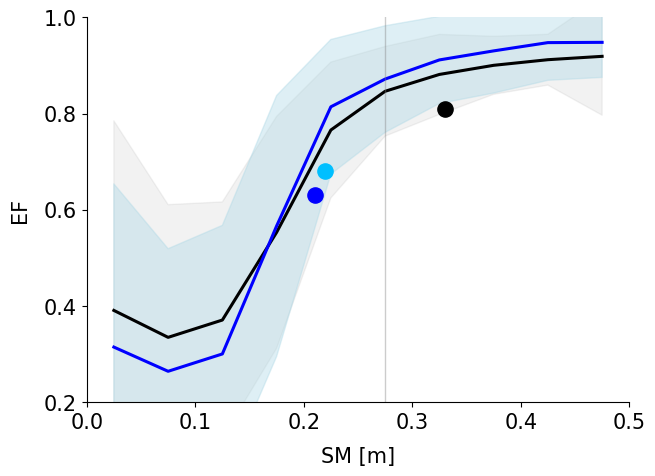

In [117]:
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(bin_centers_1, mean_ef_1, color='black', label='CTL', linewidth=2.2) # AMIP = Black
ax.plot(bin_centers_2, mean_ef_2, color='blue', label='NGCS', linewidth=2.2) # NGC = Blue
plt.fill_between(sm_bins_amip, lower_amip, upper_amip, alpha=0.1, color='grey') # blue
plt.fill_between(sm_bins_ngc, lower_ngc, upper_ngc, alpha=0.4, color='lightblue') # blue

# Error bar (std)
#plt.errorbar(sm_bins_amip, median_lh_amip, std_ef_amip, elinewidth=1, capsize=4, linewidth=0.2, c='black')
#plt.errorbar(sm_bins_ngc, median_lh_ngc, std_ef_ngc, elinewidth=1, capsize=4, linewidth=0.3, c='lightblue')


# your scatter points
ax.scatter(0.22, 0.68, color='deepskyblue', s=120, zorder=5) # NGCS
ax.scatter(0.21, 0.63, color='blue', s=120, zorder=5) # NGCE

ax.scatter(0.33, 0.81, color='black', s=120, zorder=5)
#ax.scatter(0.34, 0.82, color='orange', s=150, marker='*', alpha=0.5, zorder=5)
#ax.scatter(0.31, 0.79, color='red', s=150, marker='*', alpha=0.5, zorder=5)

# Shade regimes based on CTL
#ax.axvspan(0, sm_dry_to_trans, alpha=0.2, color='orange',   label='Dry')
#ax.axvspan(sm_dry_to_trans, sm_trans_to_wet, alpha=0.2, color='lightgreen', label='Transitional')
#ax.axvspan(sm_trans_to_wet, 0.5, alpha=0.2, color='lightblue', label='Wet')
#ax.axvline(sm_dry_to_trans, color='grey', alpha=0.4, linewidth=1)
ax.axvline(sm_trans_to_wet, color='grey', alpha=0.4, linewidth=1)


ax.set_ylim(0.2, 1)
ax.set_xlim(0.0, 0.5)
ax.spines[['right', 'top']].set_visible(False)
ax.set_ylabel('EF', fontsize=15, labelpad=10)
ax.set_xlabel('SM [m]', fontsize=15, labelpad=10)
ax.set_yticks(np.arange(0.2, 1.01, 0.2))
ax.set_xticks(np.arange(0.0, 0.51, 0.1))
ax.tick_params(labelsize=15)
#ax.set_title("Median EF vs SM")
#ax.legend()


In [73]:
sm_amip_common_f.max()

np.float32(0.60415196)

In [82]:
sm_ngc_start_amz_f.max()

np.float32(0.51430213)